# Benchmark Report Visualization

This notebook turns `summary.csv` into report-friendly figures.

Main figures:
- Accuracy heatmaps with cleaner labels and fixed model ordering
- Best configuration comparison by task
- Prompt-style trend line chart
- Prompt-style gain vs. baseline heatmap

Optional appendix figure:
- Accuracy vs. latency scatter plot


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm
    from matplotlib.lines import Line2D
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook needs matplotlib. Install it with `pip install matplotlib`."
    ) from exc

DATA_PATH = Path("summary.csv")
FIG_DIR = Path("report_figures")
FIG_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv(DATA_PATH)

numeric_cols = [
    "n_samples",
    "n_correct",
    "accuracy",
    "elapsed_sec",
    "avg_sec_per_sample",
    "generation_max_new_tokens",
    "seed",
    "limit",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["used_chat_template"] = (
    df["used_chat_template"].astype(str).str.strip().str.lower().map({"true": True, "false": False})
)

model_order = [
    model
    for model in ["deepseek_r1_1p5b","tinyllama", "qwen25_3b", "qwen3_4b"]
    if model in df["model_key"].unique()
]
task_order = [task for task in ["commonsenseqa", "openbookqa", "piqa"] if task in df["task_key"].unique()]
prompt_order = [prompt for prompt in ["baseline", "constrained", "fewshot"] if prompt in df["prompt_style"].unique()]

model_label_map = {
    "tinyllama": "TinyLlama",
    "deepseek_r1_1p5b": "DeepSeek",
    "qwen25_3b": "Qwen2.5-3B",
    "qwen3_4b": "Qwen3-4B",
}
scatter_label_map = {
    "tinyllama": "T",
    "deepseek_r1_1p5b": "D",
    "qwen25_3b": "Q25",
    "qwen3_4b": "Q3",
}
task_label_map = {
    "commonsenseqa": "CommonsenseQA",
    "openbookqa": "OpenBookQA",
    "piqa": "PIQA",
}
prompt_label_map = {
    "baseline": "Baseline",
    "constrained": "Constrained",
    "fewshot": "Few-shot",
}

prompt_palette = {
    "baseline": "#4C78A8",
    "constrained": "#F58518",
    "fewshot": "#54A24B",
}
model_palette = {
    "tinyllama": "#5C4B51",
    "deepseek_r1_1p5b": "#B56576",
    "qwen25_3b": "#45969D",
    "qwen3_4b": "#1D3257",
}

df["model_label"] = df["model_key"].map(model_label_map).fillna(df["model_key"])
df["scatter_label"] = df["model_key"].map(scatter_label_map).fillna(df["model_key"])
df["task_label"] = df["task_key"].map(task_label_map).fillna(df["task_key"])
df["prompt_label"] = df["prompt_style"].map(prompt_label_map).fillna(df["prompt_style"])

df["model_key"] = pd.Categorical(df["model_key"], categories=model_order, ordered=True)
df["task_key"] = pd.Categorical(df["task_key"], categories=task_order, ordered=True)
df["prompt_style"] = pd.Categorical(df["prompt_style"], categories=prompt_order, ordered=True)
df = df.sort_values(["task_key", "model_key", "prompt_style"]).reset_index(drop=True)


def annotated_heatmap(ax, data, title, cmap, vmin, vmax, fmt="{:.3f}", center=None):
    values = data.to_numpy(dtype=float)
    if center is None:
        im = ax.imshow(values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto", interpolation="nearest")
    else:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
        im = ax.imshow(values, cmap=cmap, norm=norm, aspect="auto", interpolation="nearest")

    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    ax.set_title(title, y=1.05)
    ax.grid(False)
    ax.tick_params(axis="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    midpoint = center if center is not None else (vmin + vmax) / 2
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            value = values[i, j]
            if np.isnan(value):
                label = "NA"
                text_color = "black"
            else:
                label = fmt.format(value)
                text_color = "white" if value >= midpoint else "black"
            ax.text(j, i, label, ha="center", va="center", color=text_color, fontsize=9)
    return im


display_cols = [
    "model_label",
    "task_label",
    "prompt_label",
    "accuracy",
    "avg_sec_per_sample",
    "n_samples",
    "used_chat_template",
]

df.head()

,model_key,model_name,task_key,prompt_style,split,n_samples,n_correct,accuracy,elapsed_sec,avg_sec_per_sample,generation_max_new_tokens,used_chat_template,seed,limit,model_label,scatter_label,task_label,prompt_label
0,deepseek_r1_1p5b,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,commonsenseqa,baseline,train,710,0,0.000000,170.109930,0.239591,8,True,42,NaN,DeepSeek,D,CommonsenseQA,Baseline
1,deepseek_r1_1p5b,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,commonsenseqa,constrained,train,710,0,0.000000,169.885582,0.239275,8,True,42,NaN,DeepSeek,D,CommonsenseQA,Constrained
2,deepseek_r1_1p5b,deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B,commonsenseqa,fewshot,train,710,0,0.000000,172.888085,0.243504,8,True,42,NaN,DeepSeek,D,CommonsenseQA,Few-shot
3,tinyllama,TinyLlama/TinyLlama_v1.1,commonsenseqa,baseline,train,710,133,0.187324,138.700097,0.195352,8,False,42,NaN,TinyLlama,T,CommonsenseQA,Baseline
4,tinyllama,TinyLlama/TinyLlama_v1.1,commonsenseqa,constrained,train,710,134,0.188732,137.613575,0.193822,8,False,42,NaN,TinyLlama,T,CommonsenseQA,Constrained


In [2]:
overview = pd.Series(
    {
        "rows": len(df),
        "models": df["model_key"].nunique(),
        "tasks": df["task_key"].nunique(),
        "prompt styles": df["prompt_style"].nunique(),
        "split": ", ".join(sorted(df["split"].astype(str).unique())),
        "seed": ", ".join(map(str, sorted(df["seed"].dropna().unique()))),
        "max_new_tokens": ", ".join(map(str, sorted(df["generation_max_new_tokens"].dropna().unique()))),
    },
    name="value",
)

display(overview.to_frame())
display(df[display_cols])

task_summary = (
    df.groupby("task_label")[["n_samples", "accuracy", "avg_sec_per_sample"]]
    .agg({"n_samples": "max", "accuracy": "mean", "avg_sec_per_sample": "mean"})
    .rename(columns={"accuracy": "mean_accuracy", "avg_sec_per_sample": "mean_sec_per_sample"})
)
task_summary


,value
rows,36
models,4
tasks,3
prompt styles,3
split,train
seed,42
max_new_tokens,8


,model_label,task_label,prompt_label,accuracy,avg_sec_per_sample,n_samples,used_chat_template
0,DeepSeek,CommonsenseQA,Baseline,0.000000,0.239591,710,True
1,DeepSeek,CommonsenseQA,Constrained,0.000000,0.239275,710,True
2,DeepSeek,CommonsenseQA,Few-shot,0.000000,0.243504,710,True
3,TinyLlama,CommonsenseQA,Baseline,0.187324,0.195352,710,False
4,TinyLlama,CommonsenseQA,Constrained,0.188732,0.193822,710,False
5,TinyLlama,CommonsenseQA,Few-shot,0.192958,0.198140,710,False
6,Qwen2.5-3B,CommonsenseQA,Baseline,0.369014,0.376954,710,True
7,Qwen2.5-3B,CommonsenseQA,Constrained,0.805634,0.106045,710,True
8,Qwen2.5-3B,CommonsenseQA,Few-shot,0.761972,0.101111,710,True
9,Qwen3-4B,CommonsenseQA,Baseline,0.447887,0.472627,710,True


,n_samples,mean_accuracy,mean_sec_per_sample
task_label,,,
CommonsenseQA,710,0.380399,0.218198
OpenBookQA,491,0.416158,0.217990
PIQA,696,0.489344,0.219630


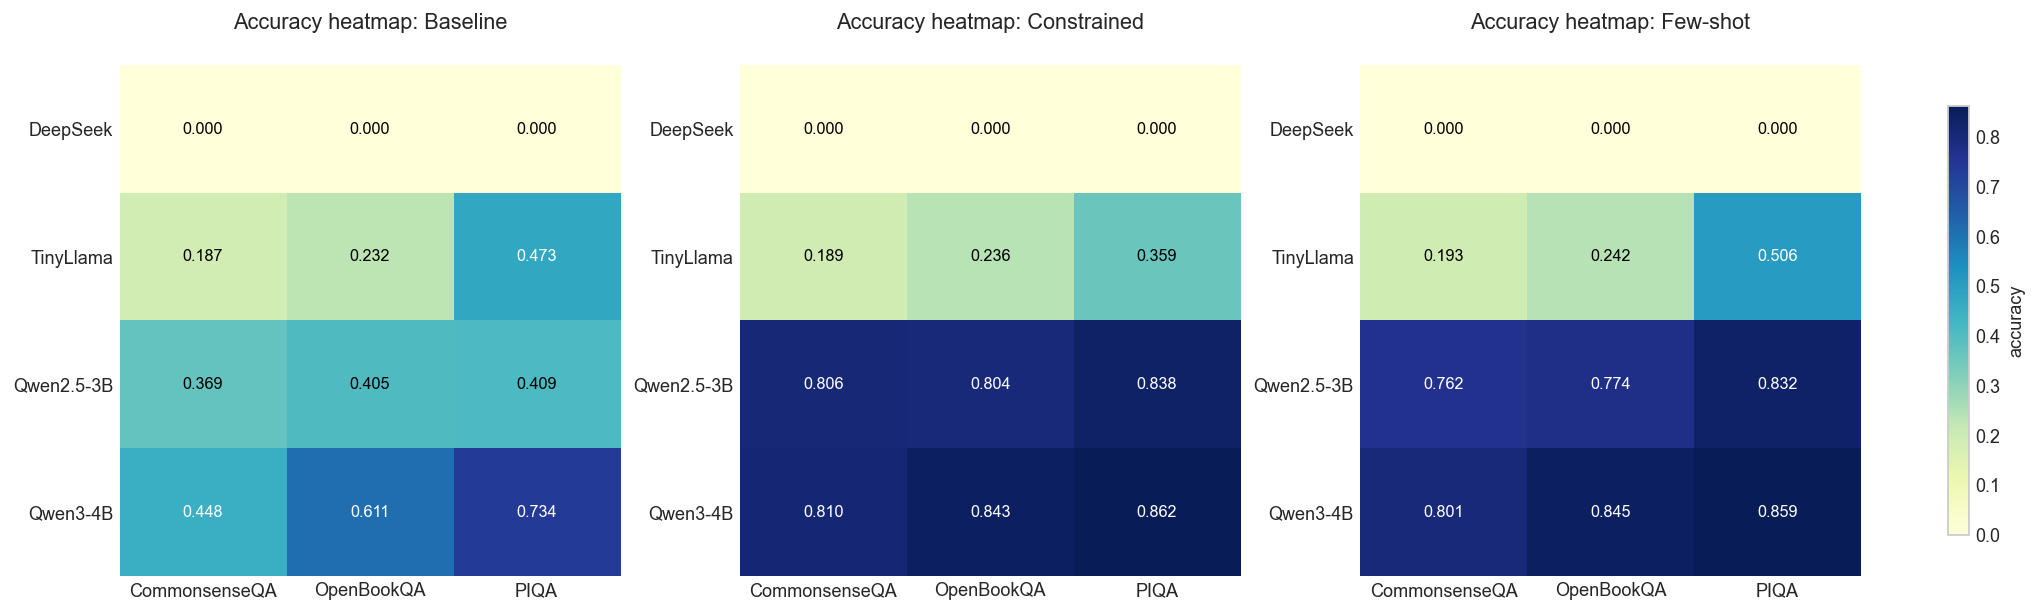

In [3]:
acc_min = float(df["accuracy"].min())
acc_max = float(df["accuracy"].max())

fig, axes = plt.subplots(1, len(prompt_order), figsize=(5.2 * len(prompt_order), 4.6), constrained_layout=True)
if len(prompt_order) == 1:
    axes = [axes]

for ax, prompt_style in zip(axes, prompt_order):
    pivot = (
        df[df["prompt_style"] == prompt_style]
        .pivot(index="model_key", columns="task_key", values="accuracy")
        .reindex(index=model_order, columns=task_order)
        .rename(index=model_label_map, columns=task_label_map)
    )
    im = annotated_heatmap(
        ax,
        pivot,
        title=f"Accuracy heatmap: {prompt_label_map[prompt_style]}",
        cmap="YlGnBu",
        vmin=acc_min,
        vmax=acc_max,
    )

fig.colorbar(im, ax=axes, shrink=0.84, label="accuracy")
fig.savefig(FIG_DIR / "accuracy_heatmap_by_prompt.png", bbox_inches="tight")
plt.show()


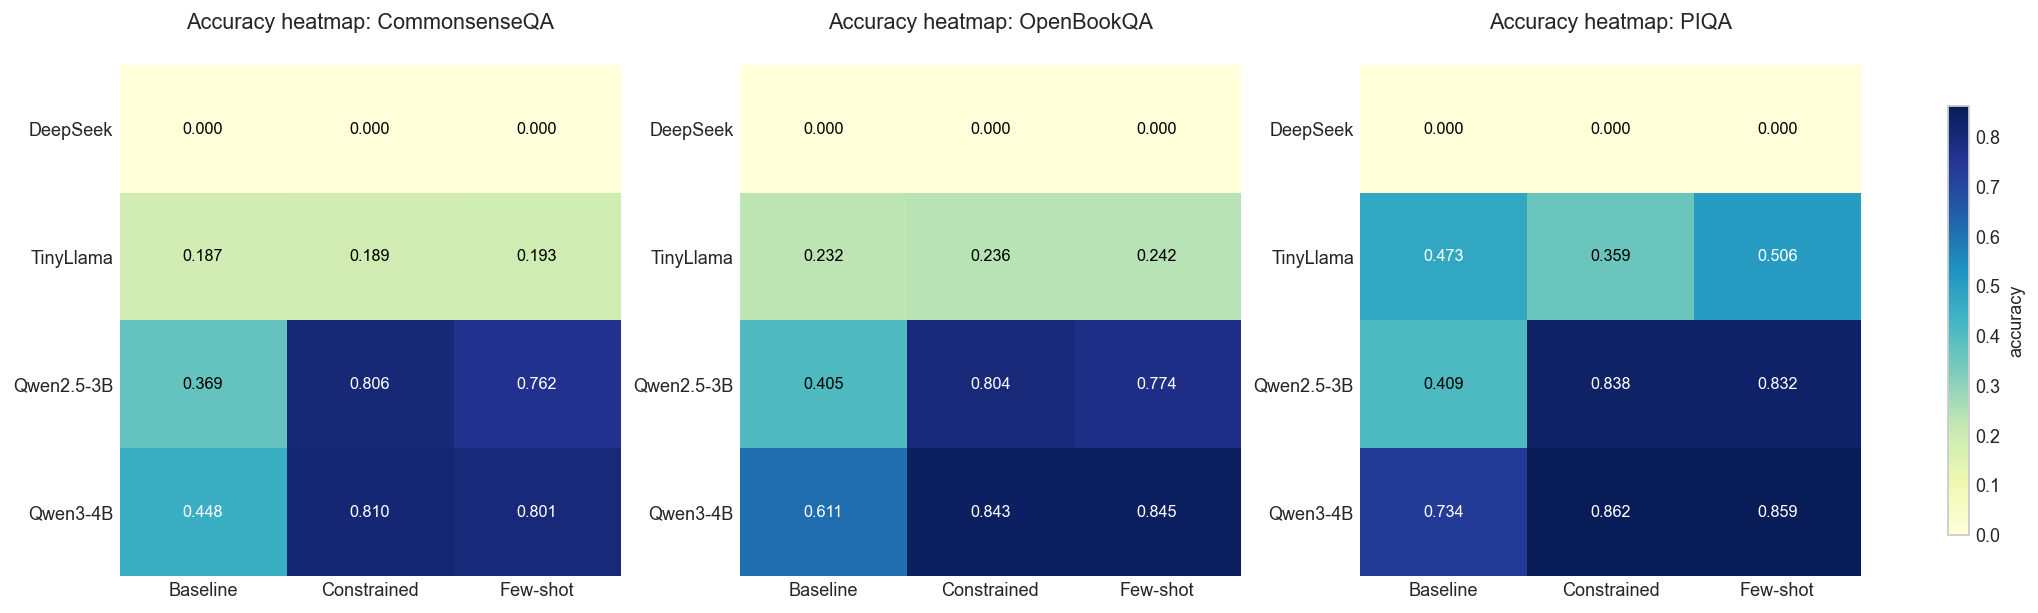

In [4]:
acc_min = float(df["accuracy"].min())
acc_max = float(df["accuracy"].max())

fig, axes = plt.subplots(1, len(task_order), figsize=(5.2 * len(task_order), 4.6), constrained_layout=True)
if len(task_order) == 1:
    axes = [axes]

for ax, task_key in zip(axes, task_order):
    pivot = (
        df[df["task_key"] == task_key]
        .pivot(index="model_key", columns="prompt_style", values="accuracy")
        .reindex(index=model_order, columns=prompt_order)
        .rename(index=model_label_map, columns=prompt_label_map)
    )
    im = annotated_heatmap(
        ax,
        pivot,
        title=f"Accuracy heatmap: {task_label_map[task_key]}",
        cmap="YlGnBu",
        vmin=acc_min,
        vmax=acc_max,
    )

fig.colorbar(im, ax=axes, shrink=0.84, label="accuracy")
fig.savefig(FIG_DIR / "accuracy_heatmap_by_task.png", bbox_inches="tight")
plt.show()


/var/folders/_t/mg2k5qv551sgn7ymm76ttqn40000gn/T/ipykernel_74620/685131379.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.sort_values(["task_key", "model_key", "accuracy", "avg_sec_per_sample"], ascending=[True, True, False, True])


,task_key,model_key,prompt_style,accuracy,avg_sec_per_sample,n_samples
3,CommonsenseQA,Qwen3-4B,Constrained,0.809859,0.127617,710
2,CommonsenseQA,Qwen2.5-3B,Constrained,0.805634,0.106045,710
1,CommonsenseQA,TinyLlama,Few-shot,0.192958,0.198140,710
0,CommonsenseQA,DeepSeek,Constrained,0.000000,0.239275,710
7,OpenBookQA,Qwen3-4B,Few-shot,0.845214,0.125475,491
6,OpenBookQA,Qwen2.5-3B,Constrained,0.804481,0.106698,491
5,OpenBookQA,TinyLlama,Few-shot,0.242363,0.201151,491
4,OpenBookQA,DeepSeek,Constrained,0.000000,0.235094,491
11,PIQA,Qwen3-4B,Constrained,0.862069,0.123510,696
10,PIQA,Qwen2.5-3B,Constrained,0.837644,0.105851,696


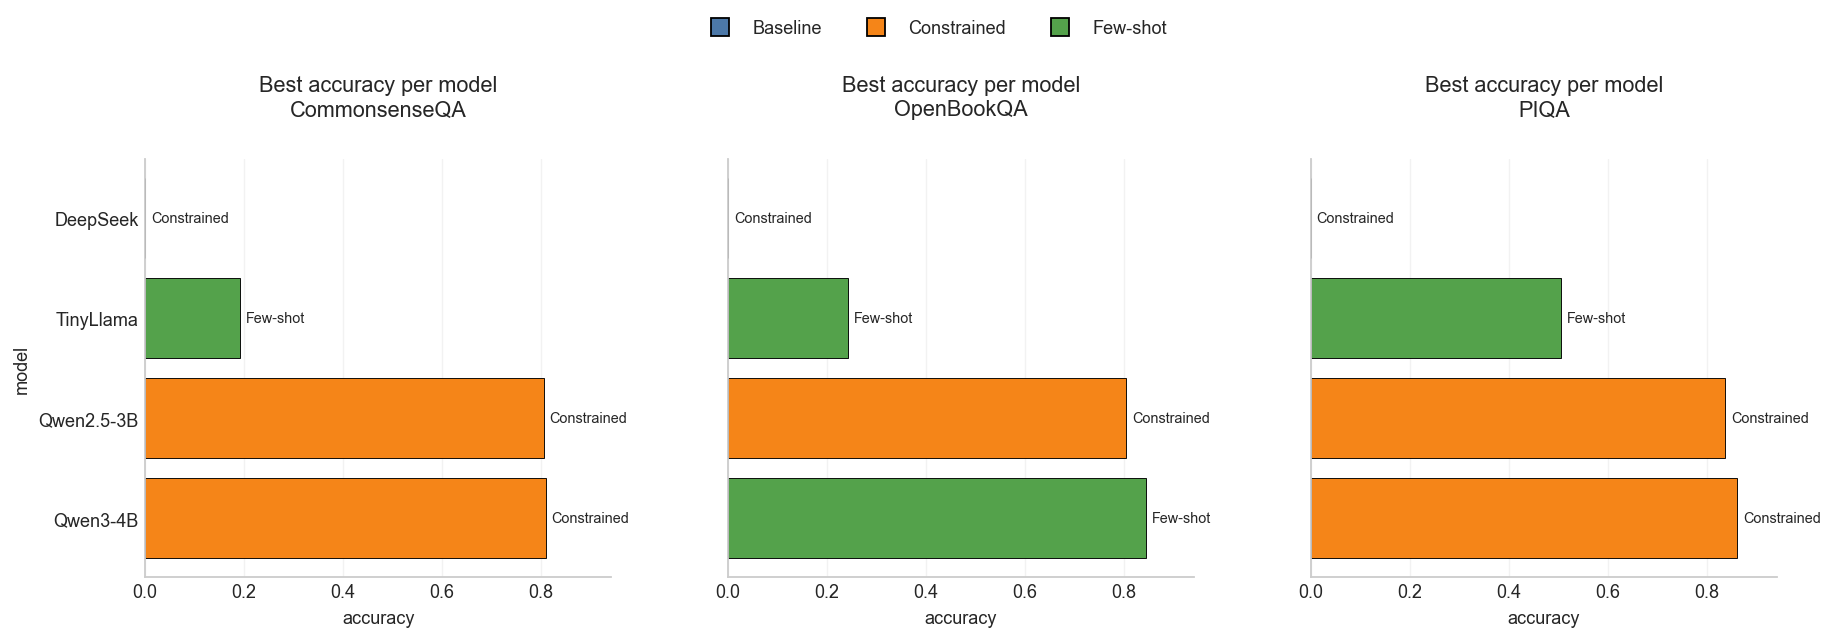

In [5]:
best_config = (
    df.sort_values(["task_key", "model_key", "accuracy", "avg_sec_per_sample"], ascending=[True, True, False, True])
    .groupby(["task_key", "model_key"], as_index=False)
    .first()
)

report_table = best_config[
    ["task_key", "model_key", "prompt_style", "accuracy", "avg_sec_per_sample", "n_samples"]
].copy()
report_table["task_key"] = report_table["task_key"].map(task_label_map)
report_table["model_key"] = report_table["model_key"].map(model_label_map)
report_table["prompt_style"] = report_table["prompt_style"].map(prompt_label_map)
report_table = report_table.sort_values(["task_key", "accuracy"], ascending=[True, False])

display(report_table)
report_table.to_csv(FIG_DIR / "report_best_config_summary.csv", index=False)

fig, axes = plt.subplots(1, len(task_order), figsize=(5.4 * len(task_order), 4.8), sharey=True)
if len(task_order) == 1:
    axes = [axes]

for ax, task_key in zip(axes, task_order):
    subset = (
        best_config[best_config["task_key"] == task_key]
        .set_index("model_key")
        .reindex(model_order)
        .reset_index()
    )
    subset["model_label"] = subset["model_key"].map(model_label_map)
    colors = [prompt_palette.get(prompt, "#999999") for prompt in subset["prompt_style"]]
    bars = ax.barh(subset["model_label"], subset["accuracy"], color=colors, edgecolor="black", linewidth=0.5)
    ax.invert_yaxis()
    ax.set_title(f"Best accuracy per model\n{task_label_map[task_key]}", y=1.08)
    ax.set_xlabel("accuracy")
    ax.set_xlim(0, min(1.0, float(df["accuracy"].max()) + 0.08))
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", visible=False)
    for bar, prompt_style in zip(bars, subset["prompt_style"]):
        ax.text(
            bar.get_width() + 0.012,
            bar.get_y() + bar.get_height() / 2,
            prompt_label_map[prompt_style],
            ha="left",
            va="center",
            fontsize=8,
        )

axes[0].set_ylabel("model")
legend_handles = [
    Line2D([0], [0], marker="s", linestyle="", markersize=10, markerfacecolor=color, markeredgecolor="black", label=prompt_label_map[prompt])
    for prompt, color in prompt_palette.items()
    if prompt in prompt_order
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.03), ncol=len(legend_handles), frameon=False)
fig.subplots_adjust(top=0.78, wspace=0.25)
fig.savefig(FIG_DIR / "best_accuracy_by_task_model.png", bbox_inches="tight")
plt.show()


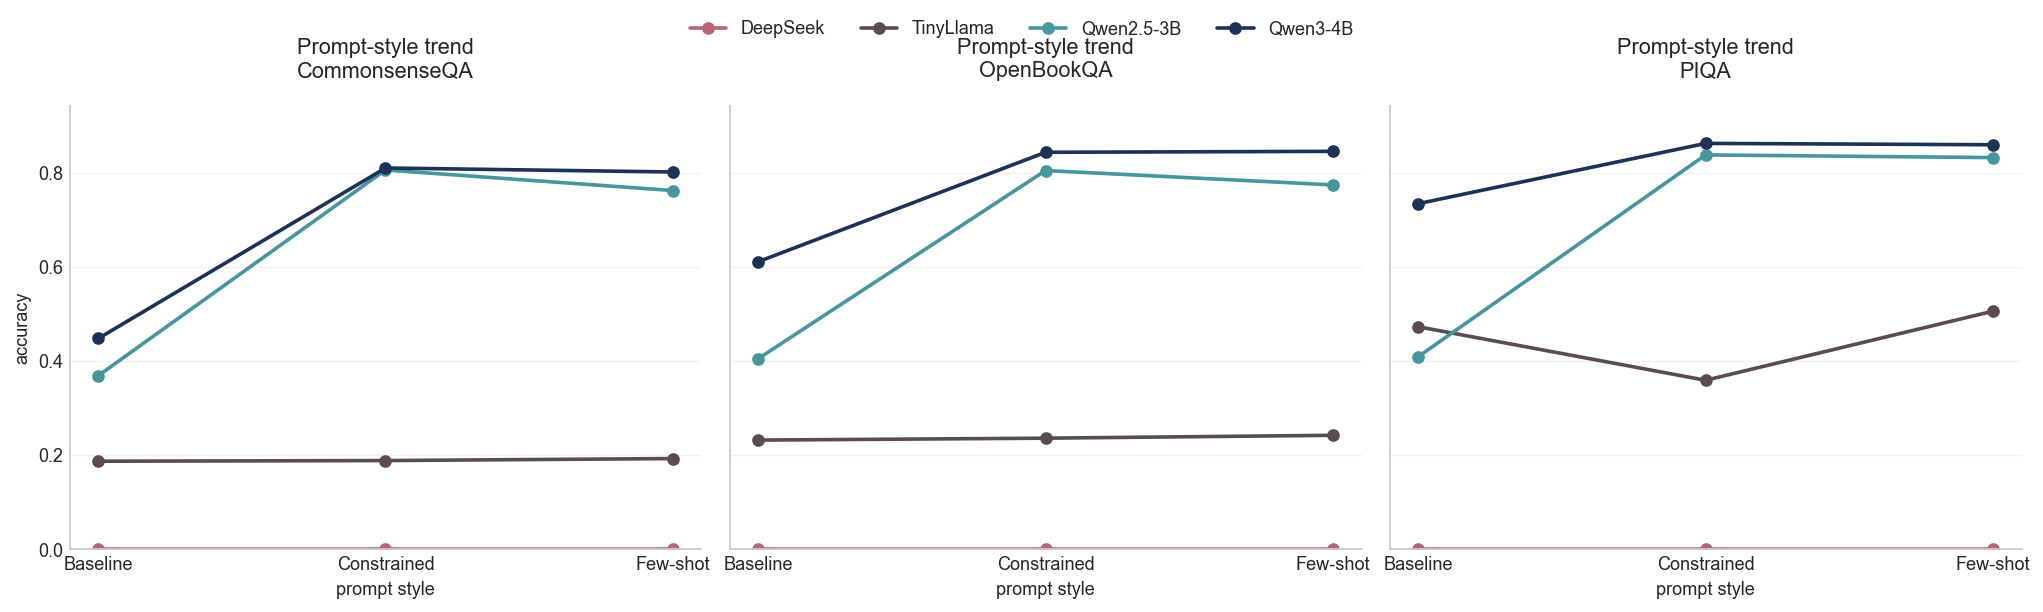

In [6]:
fig, axes = plt.subplots(1, len(task_order), figsize=(5.2 * len(task_order), 4.4), sharey=True, constrained_layout=True)
if len(task_order) == 1:
    axes = [axes]

for ax, task_key in zip(axes, task_order):
    task_slice = df[df["task_key"] == task_key]
    for model_key in model_order:
        model_slice = (
            task_slice[task_slice["model_key"] == model_key]
            .set_index("prompt_style")
            .reindex(prompt_order)
            .reset_index()
        )
        ax.plot(
            [prompt_label_map[prompt] for prompt in model_slice["prompt_style"]],
            model_slice["accuracy"],
            marker="o",
            linewidth=2,
            markersize=6,
            color=model_palette[model_key],
            label=model_label_map[model_key],
        )
    ax.set_title(f"Prompt-style trend\n{task_label_map[task_key]}", y=1.04)
    ax.set_xlabel("prompt style")
    ax.set_ylim(0, min(1.0, float(df["accuracy"].max()) + 0.08))
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

axes[0].set_ylabel("accuracy")
line_handles = [
    Line2D([0], [0], color=model_palette[model], marker="o", linewidth=2, label=model_label_map[model])
    for model in model_order
]
fig.legend(handles=line_handles, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=len(line_handles), frameon=False)
fig.savefig(FIG_DIR / "accuracy_trend_by_prompt.png", bbox_inches="tight")
plt.show()


## Optional Appendix: Accuracy vs Latency

This plot is common when a benchmark report wants to show the trade-off between quality and efficiency.
It is useful, but not essential for a course-style report focused mainly on accuracy.
You can keep it in an appendix or drop it from the main text if space is tight.


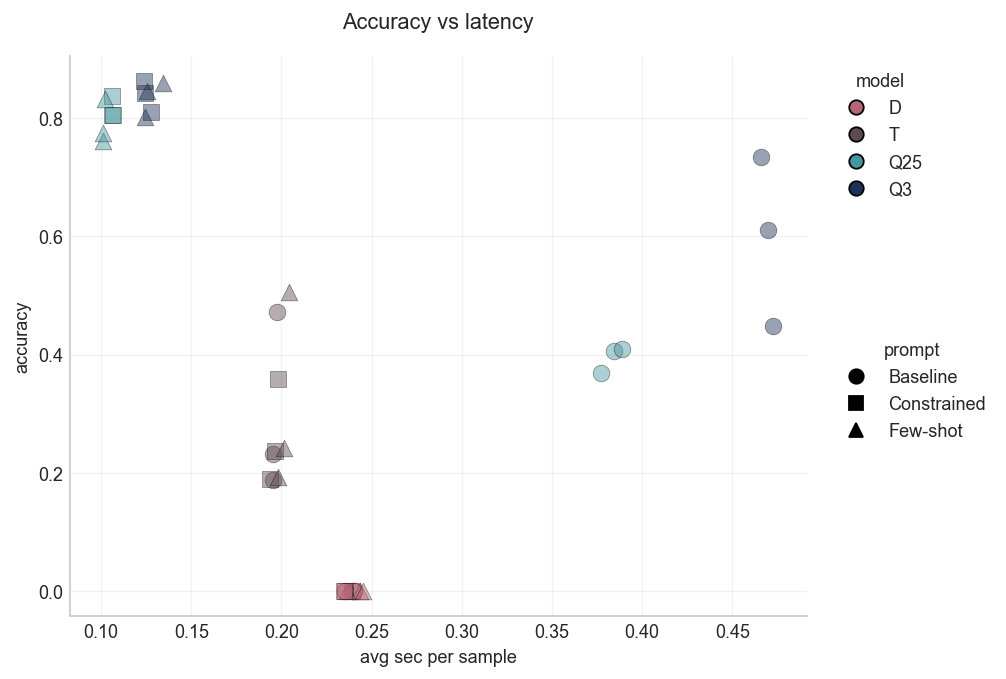

In [7]:
marker_map = {
    "baseline": "o",
    "constrained": "s",
    "fewshot": "^",
}

fig, ax = plt.subplots(figsize=(8.4, 5.6))

for _, row in df.iterrows():
    ax.scatter(
        row["avg_sec_per_sample"],
        row["accuracy"],
        s=85,
        marker=marker_map.get(row["prompt_style"], "o"),
        color=model_palette.get(row["model_key"], "#666666"),
        edgecolor="black",
        linewidth=0.4,
        alpha=0.45,
    )

ax.set_title("Accuracy vs latency", y=1.03)
ax.set_xlabel("avg sec per sample")
ax.set_ylabel("accuracy")
ax.grid(alpha=0.25)

model_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markersize=8,
        markerfacecolor=model_palette[model],
        markeredgecolor="black",
        label=scatter_label_map[model],
    )
    for model in model_order
]
prompt_handles = [
    Line2D([0], [0], marker=marker_map[prompt], linestyle="", color="black", markersize=8, label=prompt_label_map[prompt])
    for prompt in prompt_order
]

legend1 = ax.legend(handles=model_handles, title="model", bbox_to_anchor=(1.02, 1.0), loc="upper left", frameon=False)
ax.add_artist(legend1)
ax.legend(handles=prompt_handles, title="prompt", bbox_to_anchor=(1.02, 0.52), loc="upper left", frameon=False)
fig.subplots_adjust(right=0.8)
fig.savefig(FIG_DIR / "accuracy_vs_latency.png", bbox_inches="tight")
plt.show()


,model_label,task_label,prompt_label,accuracy,baseline_accuracy,accuracy_delta
7,Qwen2.5-3B,CommonsenseQA,Constrained,0.805634,0.369014,0.436620
31,Qwen2.5-3B,PIQA,Constrained,0.837644,0.409483,0.428161
19,Qwen2.5-3B,OpenBookQA,Constrained,0.804481,0.405295,0.399185
10,Qwen3-4B,CommonsenseQA,Constrained,0.809859,0.447887,0.361972
22,Qwen3-4B,OpenBookQA,Constrained,0.843177,0.610998,0.232179
34,Qwen3-4B,PIQA,Constrained,0.862069,0.734195,0.127874
16,TinyLlama,OpenBookQA,Constrained,0.236253,0.232179,0.004073
4,TinyLlama,CommonsenseQA,Constrained,0.188732,0.187324,0.001408
1,DeepSeek,CommonsenseQA,Constrained,0.000000,0.000000,0.000000
13,DeepSeek,OpenBookQA,Constrained,0.000000,0.000000,0.000000


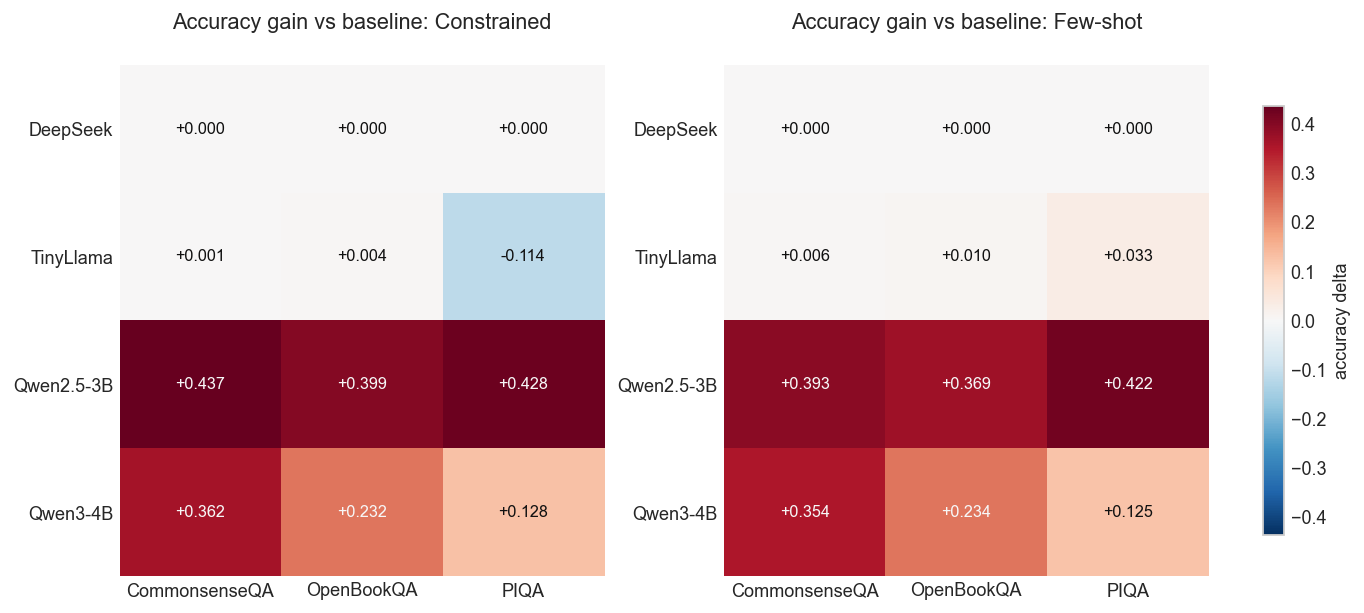

In [8]:
baseline = (
    df[df["prompt_style"] == "baseline"][["model_key", "task_key", "accuracy"]]
    .rename(columns={"accuracy": "baseline_accuracy"})
)

delta_df = df.merge(baseline, on=["model_key", "task_key"], how="left")
delta_df["accuracy_delta"] = delta_df["accuracy"] - delta_df["baseline_accuracy"]
delta_df = delta_df[delta_df["prompt_style"] != "baseline"].copy()

display(
    delta_df[["model_label", "task_label", "prompt_label", "accuracy", "baseline_accuracy", "accuracy_delta"]]
    .sort_values(["prompt_label", "accuracy_delta"], ascending=[True, False])
)

delta_prompt_order = [prompt for prompt in ["constrained", "fewshot"] if prompt in delta_df["prompt_style"].unique()]
delta_bound = float(delta_df["accuracy_delta"].abs().max()) if not delta_df.empty else 0.01
delta_bound = max(delta_bound, 0.01)


def delta_heatmap(ax, data, title, cmap="RdBu_r", vmin=-0.01, vmax=0.01, center=0.0, fmt="{:+.3f}"):
    values = data.to_numpy(dtype=float)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
    im = ax.imshow(values, cmap=cmap, norm=norm, aspect="auto", interpolation="nearest")

    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    ax.set_title(title, y=1.05)
    ax.grid(False)
    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            value = values[i, j]
            if np.isnan(value):
                label = "NA"
                text_color = "#111111"
            else:
                label = fmt.format(value)
                r, g, b, _ = im.cmap(im.norm(value))
                luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
                text_color = "#111111" if luminance > 0.6 else "#f7f7f7"

            ax.text(j, i, label, ha="center", va="center", color=text_color, fontsize=9)

    return im


fig, axes = plt.subplots(1, len(delta_prompt_order), figsize=(5.2 * len(delta_prompt_order), 4.6), constrained_layout=True)
if len(delta_prompt_order) == 1:
    axes = [axes]

for ax, prompt_style in zip(axes, delta_prompt_order):
    pivot = (
        delta_df[delta_df["prompt_style"] == prompt_style]
        .pivot(index="model_key", columns="task_key", values="accuracy_delta")
        .reindex(index=model_order, columns=task_order)
        .rename(index=model_label_map, columns=task_label_map)
    )
    im = delta_heatmap(
        ax,
        pivot,
        title=f"Accuracy gain vs baseline: {prompt_label_map[prompt_style]}",
        cmap="RdBu_r",
        vmin=-delta_bound,
        vmax=delta_bound,
        center=0.0,
        fmt="{:+.3f}",
    )

fig.colorbar(im, ax=axes, shrink=0.84, label="accuracy delta")
fig.savefig(FIG_DIR / "prompt_style_delta_heatmap.png", bbox_inches="tight")
plt.show()


In [9]:
avg_by_model = (
    df.groupby("model_key")[["accuracy", "avg_sec_per_sample"]]
    .mean()
    .reindex(model_order)
    .rename(index=model_label_map, columns={"accuracy": "mean_accuracy", "avg_sec_per_sample": "mean_sec_per_sample"})
)

prompt_style_effect = (
    delta_df.groupby("prompt_style")["accuracy_delta"]
    .agg(["mean", "median", "min", "max"])
    .rename(index=prompt_label_map)
)

display(avg_by_model)
display(prompt_style_effect)

print(f"Saved figures to: {FIG_DIR.resolve()}")
print(f"Saved best-config summary to: {(FIG_DIR / 'report_best_config_summary.csv').resolve()}")
print("Accuracy vs latency is included as an optional appendix figure, not a required main-result plot.")


/var/folders/_t/mg2k5qv551sgn7ymm76ttqn40000gn/T/ipykernel_74620/1862817261.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("model_key")[["accuracy", "avg_sec_per_sample"]]
/var/folders/_t/mg2k5qv551sgn7ymm76ttqn40000gn/T/ipykernel_74620/1862817261.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delta_df.groupby("prompt_style")["accuracy_delta"]


,mean_accuracy,mean_sec_per_sample
model_key,,
DeepSeek,0.000000,0.238787
TinyLlama,0.290828,0.197816
Qwen2.5-3B,0.666594,0.196958
Qwen3-4B,0.757112,0.240864


,mean,median,min,max
prompt_style,,,,
Baseline,NaN,NaN,NaN,NaN
Constrained,0.156497,0.065973,-0.113506,0.436620
Few-shot,0.162134,0.079023,0.000000,0.422414


Saved figures to: /Users/violet/Documents/GitHub/llm-benchmark/report_figures
Saved best-config summary to: /Users/violet/Documents/GitHub/llm-benchmark/report_figures/report_best_config_summary.csv
Accuracy vs latency is included as an optional appendix figure, not a required main-result plot.
